/opt/conda/envs/km310gpu/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')
INFO:purepyindi2.transports:Connected to localhost:7624


Directory '/data/users/kianmilani/20260722' already exists.
0.30066145520144316


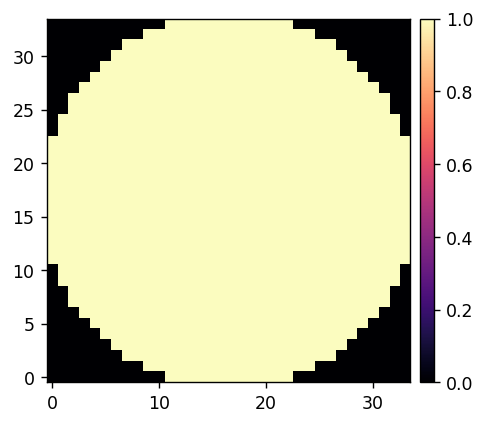

In [1]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time 
from importlib import reload
import copy
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from IPython.display import clear_output
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle, Rectangle

import lina
from lina.math_module import xp, xcipy, ensure_np_array
from lina import iefc, dm, utils, rt_utils, coro_utils, scoob_utils

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient

client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

def restart_clients():
    client0 = INDIClient('localhost', 7624)
    client0.start()

    client = IndiClient()
    client.connect()
    client.get_properties()

data_path = Path(f'/data/users/kianmilani/{today}')
utils.make_dir(data_path)

Nact = 34
ncamsci = 256
camsci_pxscl_lamDc = 1/3.326
print(camsci_pxscl_lamDc)

dm_mask = dm.create_mask(Nact=34)
utils.imshow([dm_mask])

In [2]:

CAMSCI_STREAM = ImageStream('camsci')

dm_channel = 'dm00disp04'
DM_STREAM = ImageStream(dm_channel)


In [3]:
def take_im_fun(CAMSCI_STREAM, NFRAMES=10):
    coro_im = xp.array(np.mean(CAMSCI_STREAM.grab_many(NFRAMES), axis=0))
    return coro_im

take_im_params = {
    'CAMSCI_STREAM':CAMSCI_STREAM,
    'NFRAMES':10,
}

def set_dm_fun(command, DM_STREAM, wait_time=0.02):
    DM_STREAM.write(ensure_np_array(command)*1e6)
    time.sleep(wait_time)
    return

set_dm_params = {
    'DM_STREAM':DM_STREAM,
    'wait_time':0.05,
}


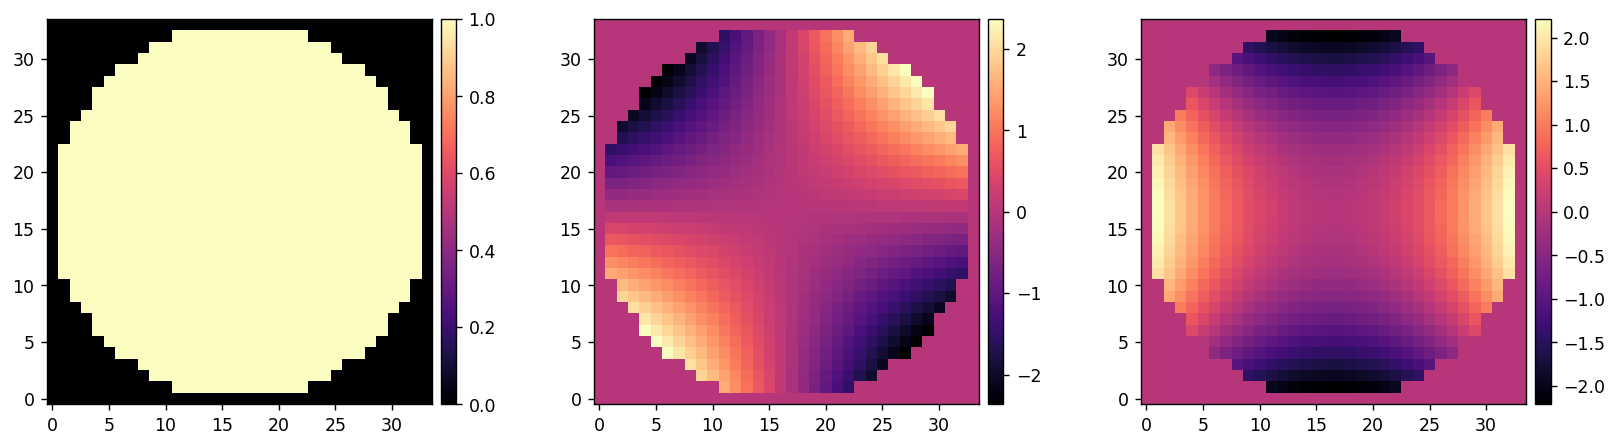

In [8]:
dm_sub_mask = utils.pad_or_crop(dm.create_mask(Nact=32), 34)
z_modes = dm.create_zernike_modes(dm_sub_mask, remove_modes=1, nmodes=10)
utils.imshow(
    [dm_sub_mask, z_modes[3], z_modes[4]]
)

In [ ]:
set_dm_fun(-1.1e-9*z_modes[4], **set_dm_params)

In [32]:
set_dm_fun(0.8e-9*z_modes[5], **set_dm_params)

In [44]:
set_dm_fun(-1.1e-9*z_modes[4] + 0.8e-9*z_modes[5], **set_dm_params)


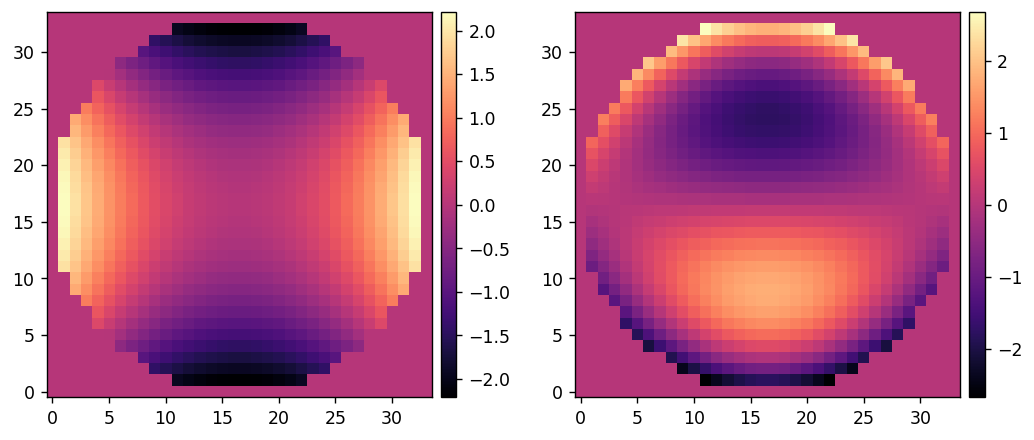

In [56]:
set_dm_fun(-1.1e-9*z_modes[4] + 1.e-9*z_modes[5] + 2e-9*z_modes[0] + -0.0e-9*z_modes[1], **set_dm_params)
utils.imshow(
    [z_modes[4], z_modes[5]],
)

In [57]:
set_dm_fun(0*z_modes[0], **set_dm_params)